Paso 1: Cargar todo

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from features import construir_features, crear_target
from database import cargar_velas
import pandas_ta as ta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Parámetros
PAR          = "ETHUSDT"
UMBRAL_PROB  = 0.63
STOP_LOSS    = 0.025
TAKE_PROFIT  = 0.010

FEATURES = [
    'close_vs_ema200', 'ema50_vs_ema200', 'ema9_vs_ema26',
    'rsi',
    'atr_relativo', 'atr_tendencia', 'bb_ancho',
    'adx', 'rsi_pendiente_vs_precio',
    'macd_histograma',
    'hora', 'dia_semana',
    'tendencia_1h', 'rsi_1h', 'adx_1h', 'roc_1h'
]

print("✅ Librerías cargadas")

✅ Librerías cargadas


Celda 2: Cargar datos y features

In [2]:
# Cargamos velas
df_15m        = cargar_velas("ETHUSDT", "15m")
df_15m['MM']  = ta.ema(df_15m['Close'], length=200)
df_15m['RSI'] = ta.rsi(df_15m['Close'], length=14)
adx           = ta.adx(df_15m['High'], df_15m['Low'],
                       df_15m['Close'], length=14)
df_15m['ADX'] = adx['ADX_14']
sar           = ta.psar(df_15m['High'], df_15m['Low'],
                        df_15m['Close'])
df_15m['SAR'] = sar['PSARl_0.02_0.2'].fillna(
                    sar['PSARs_0.02_0.2'])
df_15m        = df_15m.dropna()

# Features y target
features_df, _ = construir_features("ETHUSDT")
target         = crear_target(
    df_15m.loc[features_df.index],
    stop_loss=STOP_LOSS,
    take_profit=TAKE_PROFIT,
    max_velas=96
)
features_df = features_df.join(target).dropna()

print(f"Velas cargadas:   {len(df_15m):,}")
print(f"Features listas:  {len(features_df):,}")
print(f"\nPrimeras 3 filas de features:")
features_df[FEATURES].tail(3)

Cargando datos ETHUSDT...
  15m: 71,134 velas
  1h:  17,634 velas

✅ Features construidas: 70,535 filas x 13 columnas
   Período: 2024-06-10 09:00:00 → 2026-06-15 02:30:00
Velas cargadas:   71,134
Features listas:  70,439

Primeras 3 filas de features:


,close_vs_ema200,ema50_vs_ema200,atr_relativo,atr_tendencia,bb_ancho,rsi,adx,hora,dia_semana,tendencia_1h,rsi_1h,adx_1h
time,,,,,,,,,,,,
2026-06-14 02:00:00,0.007873,0.004706,0.002024,-0.014953,0.006718,58.088546,35.099671,2,6,0,56.350506,33.186435
2026-06-14 02:15:00,0.006480,0.004712,0.002020,-0.066245,0.005680,52.717830,35.280564,2,6,0,56.350506,33.186435
2026-06-14 02:30:00,0.005841,0.004700,0.001965,-0.063916,0.005075,50.519931,35.187515,2,6,0,56.350506,33.186435


Celda 3: Entrenar el modelo con la primera ventana

In [3]:
# Usamos la misma lógica que backtesting_ml.py
# Ventana 1: entrenamos con 20% de los datos
n         = len(features_df)
tam_test  = n // 5
fin_train = tam_test * (1 + 3)
fin_test  = tam_test * (2 + 3)

f_train = features_df.iloc[:fin_train]
f_test  = features_df.iloc[fin_train:fin_test]

X_train  = f_train[FEATURES]
y_train  = f_train['target']

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

modelo = LogisticRegression(max_iter=1000,
                            class_weight='balanced')
modelo.fit(X_scaled, y_train)

print(f"Entrenado con: {len(f_train):,} muestras")
print(f"Test con:      {len(f_test):,} muestras")
print(f"Período train: {f_train.index[0].date()} → "
      f"{f_train.index[-1].date()}")
print(f"Período test:  {f_test.index[0].date()} → "
      f"{f_test.index[-1].date()}")

Entrenado con: 56,348 muestras
Test con:      14,087 muestras
Período train: 2024-06-10 → 2026-01-18
Período test:  2026-01-18 → 2026-06-14


Celda 4: Ver las probabilidades vela por vela

In [4]:
# Calculamos probabilidades para el período de test
X_test   = f_test[FEATURES]
X_scaled = scaler.transform(X_test)
probs    = modelo.predict_proba(X_scaled)[:, 1]

# Creamos tabla de decisiones
tabla = pd.DataFrame({
    'fecha':        f_test.index,
    'close':        df_15m.loc[f_test.index, 'Close'].values,
    'prob':         probs.round(3),
    'rsi_1h':       f_test['rsi_1h'].values.round(1),
    'atr_relativo': f_test['atr_relativo'].values.round(4),
    'tendencia_1h': f_test['tendencia_1h'].values.astype(int),
    'decision':     ['🟢 COMPRAR' if p >= UMBRAL_PROB
                     else '🔴 NO operar' for p in probs]
})

print(f"Total velas analizadas: {len(tabla):,}")
print(f"Señales de compra:      "
      f"{(probs >= UMBRAL_PROB).sum():,} "
      f"({(probs >= UMBRAL_PROB).mean()*100:.1f}%)")
print(f"\nMuestra de 20 velas aleatorias:")
tabla.sample(20).sort_values('fecha')

Total velas analizadas: 14,087
Señales de compra:      1,254 (8.9%)

Muestra de 20 velas aleatorias:


,fecha,close,prob,rsi_1h,atr_relativo,tendencia_1h,decision
255,2026-01-20 23:45:00,2939.88,0.273,13.9,0.0053,0,🔴 NO operar
299,2026-01-21 10:45:00,2963.92,0.326,33.3,0.0031,0,🔴 NO operar
3581,2026-02-24 15:15:00,1849.13,0.487,48.9,0.0059,0,🔴 NO operar
3856,2026-02-27 12:00:00,1960.95,0.449,30.5,0.0060,0,🔴 NO operar
4488,2026-03-06 02:00:00,2091.89,0.382,47.0,0.0049,1,🔴 NO operar
4832,2026-03-09 16:00:00,2023.62,0.623,67.4,0.0060,1,🔴 NO operar
4989,2026-03-11 07:15:00,2019.46,0.370,42.6,0.0035,1,🔴 NO operar
5193,2026-03-13 10:15:00,2125.20,0.522,65.0,0.0045,1,🔴 NO operar
5560,2026-03-17 06:00:00,2315.41,0.518,57.2,0.0066,1,🔴 NO operar
5680,2026-03-18 12:00:00,2259.84,0.367,28.5,0.0049,1,🔴 NO operar


Celda 5: Ver SOLO las operaciones ejecutadas

In [5]:
# Filtramos solo los momentos donde el modelo dijo COMPRAR
señales_compra = tabla[tabla['prob'] >= UMBRAL_PROB].copy()

print(f"Operaciones de compra en el período de test: "
      f"{len(señales_compra):,}")
print(f"\nPrimeras 20 señales de compra:")
señales_compra

Operaciones de compra en el período de test: 1,262

Primeras 20 señales de compra:


,fecha,close,prob,rsi_1h,atr_relativo,tendencia_1h,decision
28,2026-01-18 15:00:00,3326.05,0.669,64.4,0.0021,1,🟢 COMPRAR
29,2026-01-18 15:15:00,3331.97,0.634,64.4,0.0022,1,🟢 COMPRAR
36,2026-01-18 17:00:00,3332.50,0.713,69.9,0.0020,1,🟢 COMPRAR
37,2026-01-18 17:15:00,3336.75,0.692,69.9,0.0020,1,🟢 COMPRAR
38,2026-01-18 17:30:00,3335.15,0.702,69.9,0.0019,1,🟢 COMPRAR
...,...,...,...,...,...,...,...
13945,2026-06-12 14:15:00,1670.55,0.656,58.6,0.0038,0,🟢 COMPRAR
13946,2026-06-12 14:30:00,1668.83,0.670,58.6,0.0039,0,🟢 COMPRAR
14046,2026-06-13 15:30:00,1679.76,0.638,59.8,0.0018,0,🟢 COMPRAR
14068,2026-06-13 21:00:00,1675.41,0.679,61.5,0.0017,0,🟢 COMPRAR


Celda 6: Ver qué pasó DESPUÉS de cada compra

In [6]:
# Esta es la celda más importante
# Para cada señal de compra, vemos qué pasó con el precio

resultados = []
df_test = df_15m.loc[f_test.index]

for idx, row in señales_compra.iterrows():
    pos_actual = df_test.index.get_loc(row['fecha'])
    precio_entrada = float(df_test.iloc[pos_actual + 1]['Open']) \
                     if pos_actual + 1 < len(df_test) else None

    if precio_entrada is None:
        continue

    precio_tp = precio_entrada * (1 + TAKE_PROFIT)
    precio_sl = precio_entrada * (1 - STOP_LOSS)

    # Miramos las próximas 96 velas
    resultado = 'TIEMPO'  # si no toca ni TP ni SL
    precio_salida = None
    velas_abiertas = 0

    for j in range(pos_actual + 1,
                   min(pos_actual + 97, len(df_test))):
        vela = df_test.iloc[j]
        velas_abiertas += 1
        if vela['High'] >= precio_tp:
            resultado = '✅ TAKE PROFIT'
            precio_salida = precio_tp
            break
        if vela['Low'] <= precio_sl:
            resultado = '❌ STOP LOSS'
            precio_salida = precio_sl
            break

    if precio_salida:
        ganancia = (precio_salida / precio_entrada - 1) * 100
    else:
        ultimo = float(df_test.iloc[
            min(pos_actual + 96, len(df_test)-1)]['Close'])
        ganancia = (ultimo / precio_entrada - 1) * 100
        precio_salida = ultimo

    resultados.append({
        'fecha_entrada':  pd.to_datetime(row['fecha']).strftime('%Y-%m-%d %H:%M'),
        'precio_entrada': round(precio_entrada, 2),
        'precio_salida':  round(precio_salida, 2),
        'ganancia_%':     round(ganancia, 3),
        'resultado':      resultado,
        'prob_modelo':    round(row['prob'], 3),
        'rsi_1h':         round(row['rsi_1h'], 1),
        'velas_abiertas': velas_abiertas
    })

df_resultados = pd.DataFrame(resultados)
print(f"Operaciones analizadas: {len(df_resultados)}")
print(f"Ganadoras:  "
      f"{len(df_resultados[df_resultados['ganancia_%'] > 0])}")
print(f"Perdedoras: "
      f"{len(df_resultados[df_resultados['ganancia_%'] <= 0])}")
print()
df_resultados

Operaciones analizadas: 1262
Ganadoras:  922
Perdedoras: 340



,fecha_entrada,precio_entrada,precio_salida,ganancia_%,resultado,prob_modelo,rsi_1h,velas_abiertas
0,2026-01-18 15:00,3326.05,3359.31,1.0,✅ TAKE PROFIT,0.669,64.4,13
1,2026-01-18 15:15,3331.97,3365.29,1.0,✅ TAKE PROFIT,0.634,64.4,12
2,2026-01-18 17:00,3332.50,3365.82,1.0,✅ TAKE PROFIT,0.713,69.9,6
3,2026-01-18 17:15,3336.74,3253.32,-2.5,❌ STOP LOSS,0.692,69.9,27
4,2026-01-18 17:30,3335.14,3368.49,1.0,✅ TAKE PROFIT,0.702,69.9,4
...,...,...,...,...,...,...,...,...
1257,2026-06-12 14:15,1670.54,1687.25,1.0,✅ TAKE PROFIT,0.656,58.6,3
1258,2026-06-12 14:30,1668.82,1685.51,1.0,✅ TAKE PROFIT,0.670,58.6,1
1259,2026-06-13 15:30,1679.75,1696.55,1.0,✅ TAKE PROFIT,0.638,59.8,24
1260,2026-06-13 21:00,1675.41,1692.16,1.0,✅ TAKE PROFIT,0.679,61.5,2


Celda 7: Gráfico de una operación específica

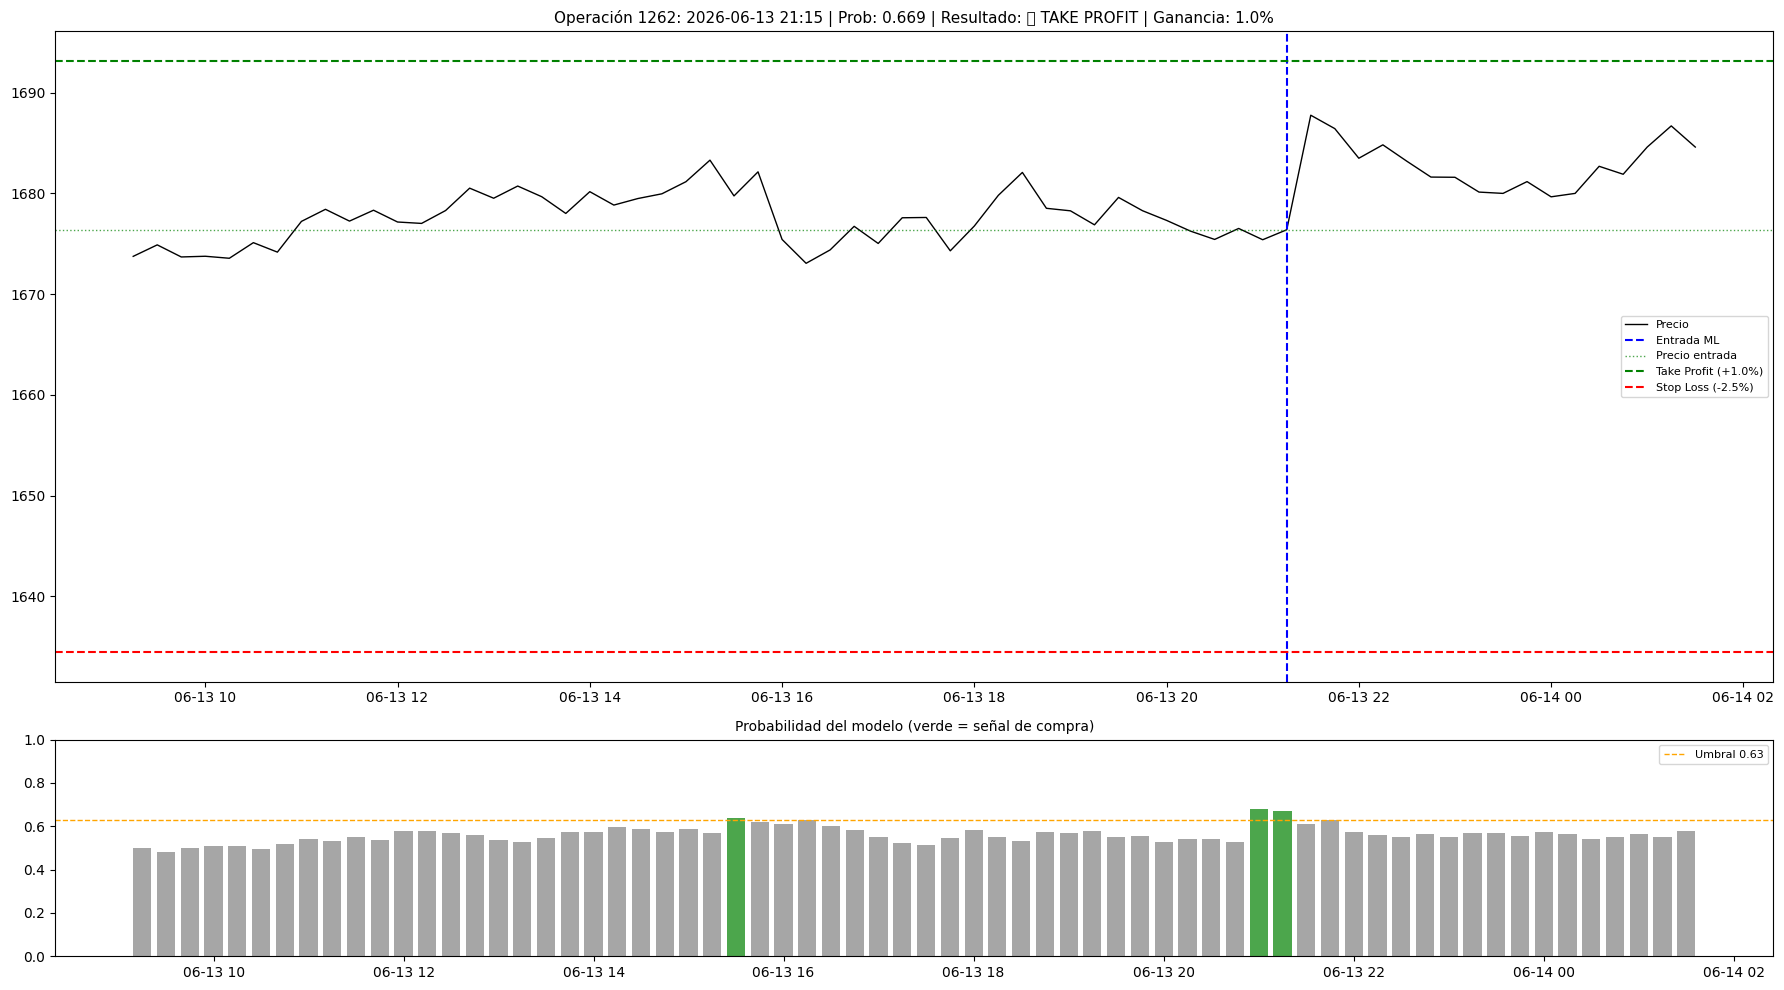


Detalle de la operación 1262:
  Fecha entrada:   2026-06-13 21:15
  Precio entrada:  $1676.4
  Precio salida:   $1693.16
  Resultado:       ✅ TAKE PROFIT
  Ganancia:        1.0%
  Prob. modelo:    0.669
  RSI 1h:          61.5
  Velas abiertas:  1 (0h 15min)


In [8]:
# Elegí cualquier número de operación para verla en detalle
N_OPERACION = 1261  # cambiá este número para ver otras

op = df_resultados.iloc[N_OPERACION]
fecha_entrada = pd.to_datetime(op['fecha_entrada'])

# Tomamos 48 velas antes y 96 después
pos = df_test.index.get_loc(
    df_test.index[df_test.index >= fecha_entrada][0]
)
inicio = max(0, pos - 48)
fin    = min(len(df_test), pos + 97)
df_plot = df_test.iloc[inicio:fin]

fig, axs = plt.subplots(2, 1, figsize=(18, 10),
                        gridspec_kw={'height_ratios': [3, 1]})

# Panel precio
axs[0].plot(df_plot.index, df_plot['Close'],
            lw=1, color='black', label='Precio')
axs[0].axvline(fecha_entrada, color='blue',
               lw=1.5, ls='--', label='Entrada ML')
axs[0].axhline(op['precio_entrada'], color='green',
               lw=1, ls=':', alpha=0.7, label='Precio entrada')
axs[0].axhline(op['precio_entrada'] * (1 + TAKE_PROFIT),
               color='green', lw=1.5, ls='--',
               label=f'Take Profit (+{TAKE_PROFIT*100}%)')
axs[0].axhline(op['precio_entrada'] * (1 - STOP_LOSS),
               color='red', lw=1.5, ls='--',
               label=f'Stop Loss (-{STOP_LOSS*100}%)')
axs[0].set_title(
    f"Operación {N_OPERACION+1}: "
    f"{op['fecha_entrada']} | "
    f"Prob: {op['prob_modelo']} | "
    f"Resultado: {op['resultado']} | "
    f"Ganancia: {op['ganancia_%']}%",
    fontsize=11
)
axs[0].legend(fontsize=8)

# Panel probabilidades del modelo
probs_plot = probs[inicio:fin]
colores    = ['green' if p >= UMBRAL_PROB else 'gray'
              for p in probs_plot]
axs[1].bar(df_plot.index, probs_plot,
           color=colores, alpha=0.7, width=0.008)
axs[1].axhline(UMBRAL_PROB, color='orange',
               lw=1, ls='--', label=f'Umbral {UMBRAL_PROB}')
axs[1].set_title("Probabilidad del modelo (verde = señal de compra)",
                 fontsize=10)
axs[1].set_ylim(0, 1)
axs[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nDetalle de la operación {N_OPERACION+1}:")
print(f"  Fecha entrada:   {op['fecha_entrada']}")
print(f"  Precio entrada:  ${op['precio_entrada']}")
print(f"  Precio salida:   ${op['precio_salida']}")
print(f"  Resultado:       {op['resultado']}")
print(f"  Ganancia:        {op['ganancia_%']}%")
print(f"  Prob. modelo:    {op['prob_modelo']}")
print(f"  RSI 1h:          {op['rsi_1h']}")
print(f"  Velas abiertas:  {op['velas_abiertas']} "
      f"({op['velas_abiertas']*15//60}h {op['velas_abiertas']*15%60}min)")